# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [ ] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [ ] change OS to 1/10,
- [ ] 1/10 OS and scf bop
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [4]:
DS = Dataset('Fe-Mo')

# Targets

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


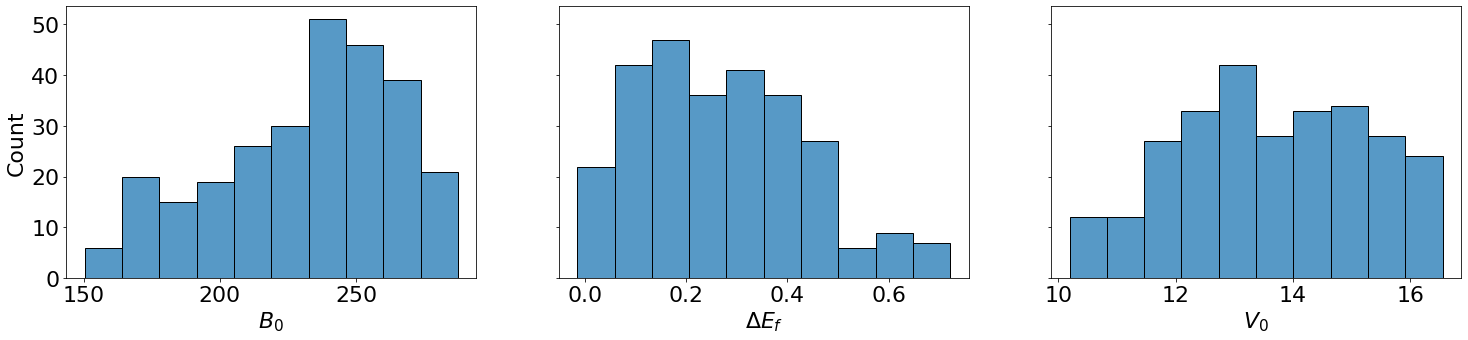

In [5]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS['EF'], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel('$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions.eps')

# Machine Learning 

In [6]:
from Tools.DatasetTools.MLConveniences import *

In [7]:
resultslocation = DS.resultslocation

## Feature sets

In [8]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [9]:
Features['Canonical BOP']

,Structure,Mag,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,...,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,random
Fe_pv8Mo_sv22.sigma-BBABB.FM,10,0,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.251469
Fe_pv10Mo_sv20.sigma-ABBAB.FM,10,0,-78.594335,-7.771059,-1.424594,0.000000,-5.906606,-0.439859,0.000000,1.201761,...,0.668575,0.166260,0.000000,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000,0.086076
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,0,-94.449166,-8.534487,-7.595698,0.000000,0.000000,0.000000,-0.938789,1.303069,...,0.000000,0.000000,0.501537,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327,0.593914
Fe_pv5Mo_sv24.chi-AABB.FM,6,0,-116.205661,-8.244366,-6.070495,-1.652565,0.000000,0.000000,-0.521305,1.162619,...,0.000000,0.000000,0.186186,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205,0.449737
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,1,-121.105805,-8.136275,-2.533063,0.000000,-0.844603,-0.318349,-4.440260,1.218738,...,0.256809,0.124851,0.170809,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607,0.871217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,9,1,-40.035290,-8.020136,-2.520056,0.000000,-0.663807,-0.397166,-4.439107,1.265062,...,0.220371,0.224323,0.222761,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884,0.201132
Fe_pv8Mo_sv22.sigma-BBABB.NM,10,1,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.235389
Fe_pv1Mo_sv3.L12-AB3.FM,7,0,-12.617373,-6.832601,-6.832601,0.000000,0.000000,0.000000,0.000000,1.063750,...,0.000000,0.000000,0.000000,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000,0.656293
Fe_pv8Mo_sv22.sigma-BBBBA.FM,10,0,-94.569986,-7.892530,-5.305761,0.000000,-2.136368,-0.450401,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.051374


In [10]:
Features.keys()

dict_keys(['atomic', 'dataset', 'Pyscal', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', 'Projections sOS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + Projections sOS BOP'])

## BOP features with and without CP averages

In [11]:
def clean_CNAVS(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [12]:
def clean_zeros(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [13]:
def notyetclean(name:str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [14]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name) } )

In [15]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [16]:
samplesplit = DS.get_samplesplit()

# Models: adjust params

In [17]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
}

In [18]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [19]:
MO.load_model_options('Kernel Ridge')

In [20]:
MO.modeloptions['Kernel Ridge']

{'regressor__alpha': [0.1, 0.01, 0.001, 0.0001],
 'regressor__kernel': ['rbf', 'polynomial'],
 'regressor__degree': [4, 5, 6, 7],
 'regressor__coef0': [0, 1, 10]}

In [21]:
samplefolds = list(DS.get_folds())

# fits

In [22]:
fittedmodelslocation = os.path.join(DS.resultslocation, 'KRR_FittedCVSearch.pkl')

if os.path.exists(fittedmodelslocation):
    with open(fittedmodelslocation, 'rb') as pkl:
        FittedModels = pickle.load(pkl)

In [23]:
for name, model in Models.items():
    print (name)
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        if 'no CNAV' in key:
            continue
        if (name, key) in FittedModels.keys():
            continue
        model = GridSearchCV(
            Models[name],
            Parameters[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        FittedModels[(name, key)] = model.fit(features, DS.target)

Kernel Ridge


  0%|          | 0/19 [00:00<?, ?it/s]

In [24]:
with open(fittedmodelslocation, 'wb') as pkl:
    pickle.dump(FittedModels, pkl)

In [25]:
def collect_best_scores(FittedModels: dict[tuple, RegressorMixin]):
    best_scores = {}
    for key, fittedmodel in FittedModels.items():
        results = pd.DataFrame.from_dict(fittedmodel.cv_results_).sort_values(by='mean_test_score', ascending=False)[['mean_test_score', 'mean_train_score']]
        best_scores[key] = {'test': np.abs(results['mean_test_score']).min(), 'train':np.abs(results['mean_train_score']).min() }
    best_scores = pd.DataFrame.from_dict(best_scores, orient='index')
    best_scores.index = pd.MultiIndex.from_tuples(best_scores.index)
    best_scores.sort_values(by='test', ascending=True, inplace=True)
    best_scores.sort_index(level=0, sort_remaining=False, ascending=True, inplace=True)
    return best_scores

In [26]:
best_scores = collect_best_scores(FittedModels)

In [27]:
best_combi = best_scores.idxmin()['test']

In [28]:
best_combi

('Kernel Ridge', 'dataset + Projections OS BOP')

In [29]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)

In [30]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [31]:
best_scores.loc[best_combi]

test     3.712228e-02
train    1.433789e-09
Name: (Kernel Ridge, dataset + Projections OS BOP), dtype: float64

In [32]:
results.loc[7].params

{'regressor__alpha': 0.1,
 'regressor__coef0': 0,
 'regressor__degree': 7,
 'regressor__kernel': 'polynomial'}

In [33]:
for parameters in MO.modeloptions.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

param_regressor__alpha
0.0001   -0.041152
0.0010   -0.040366
0.0100   -0.038317
0.1000   -0.037122
Name: mean_test_score, dtype: float64
param_regressor__kernel
polynomial   -0.037122
rbf          -0.057806
Name: mean_test_score, dtype: float64
param_regressor__degree
4   -0.037866
5   -0.037122
6   -0.037577
7   -0.039100
Name: mean_test_score, dtype: float64
param_regressor__coef0
0    -0.057806
1    -0.037122
10   -0.051087
Name: mean_test_score, dtype: float64


In [34]:
FittedModels[best_combi].best_params_

{'regressor__alpha': 0.1,
 'regressor__coef0': 1,
 'regressor__degree': 5,
 'regressor__kernel': 'polynomial'}

In [35]:
best_scores

test         train
Kernel Ridge dataset + Projections OS BOP   0.037122  1.433789e-09
             Projections OS BOP             0.039410  2.901050e-09
             dataset + Projections BOP      0.040358  1.216906e-09
             Projections BOP                0.040572  2.355569e-09
             dataset + Projections sOS BOP  0.042194  1.250296e-09
             Projections sOS BOP            0.042764  2.690216e-09
             dataset + Canonical BOP        0.052098  1.127543e-07
             dataset                        0.069591  6.017576e-10
             Canonical BOP                  0.072036  5.195019e-04
             Pyscal                         0.170910  1.161029e-01
             atomic                         0.173327  8.797923e-02

(0.0, 0.1)

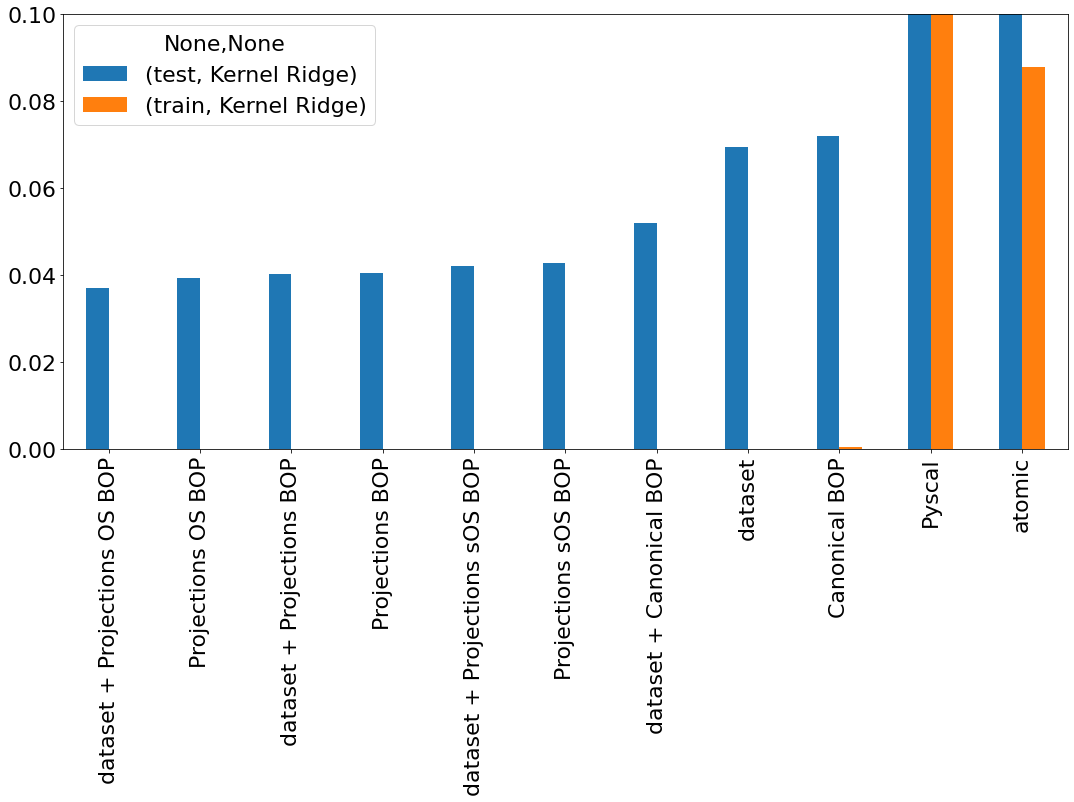

In [36]:
ax = best_scores.unstack(level=0).sort_values(by=('test','Kernel Ridge')).plot.bar()
ax.set_ylim([0,0.1])


# Prediction line 

In [37]:
Prediction = {fname: model.predict(features) for (fname, features), model in zip(Features.items(),FittedModels.values())}

In [38]:
#iwanttoplot = {'atomic':'Matminer',
iwanttoplot = {'Canonical BOP':'Canonical BOP',  best_combi[1]: best_combi[1]}

In [39]:
pallete = sns.color_palette('magma_r', n_colors=len(iwanttoplot))

In [40]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


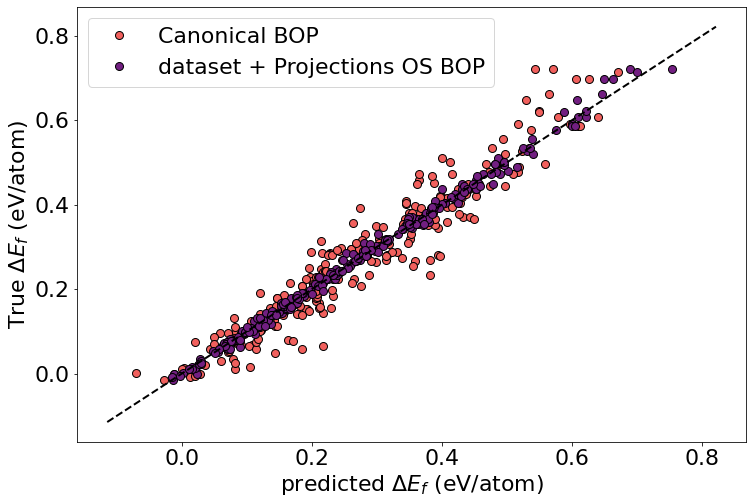

In [41]:
fig, ax = plt.subplots(figsize=(12,8))
for (name, legend), color in zip(iwanttoplot.items(), pallete):
    ax.plot(Prediction[name], DS.target, 'o', markersize=8, markeredgecolor='k',  color = color, label=legend)
#    sns.scatterplot(Prediction[name], DS.target,ax=ax) #, markersize=8, markeredgecolor='k',  color = color, label=legend)
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
ax.plot(x_y, x_y, '--k', lw=2)
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_predictionline.eps'))

# Recursivity

In [42]:
Tester = DatasetTester()

In [43]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#from Tools.DatasetTools.DatasetOperator import Dataset
#DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
#Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#samplesplit = DS.get_samplesplit()

In [44]:
import copy

In [45]:
RecursivityModels = copy.deepcopy(FittedModels)

In [46]:
test_scores = Tester.make_recursivity_anbn(DS, RecursivityModels, {'includemag':False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Tools/DatasetTools/DatasetOperator.py:220: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  axes.plot(


(<Figure size 1296x576 with 1 Axes>,
 <AxesSubplot:xlabel='number of features', ylabel='test RMSE @ $\\Delta E_f$'>)

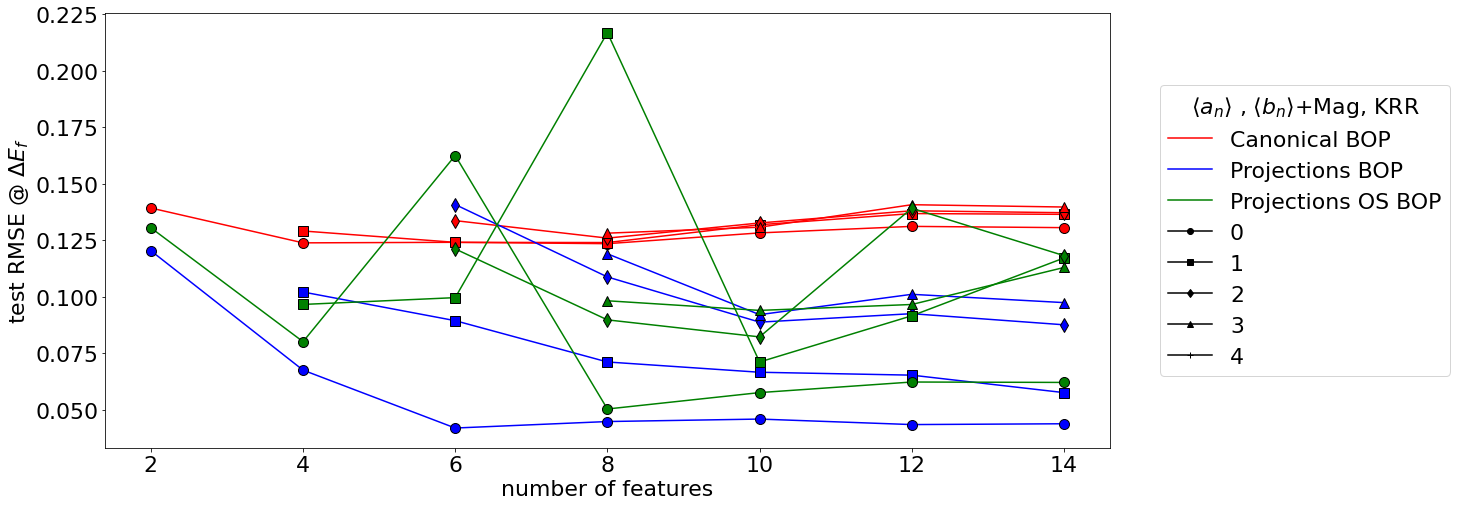

In [47]:
Tester.plot_recursivity_curve(test_scores, 'Kernel Ridge', )

In [48]:
fig.savefig(f'{DS.dataset}/graphs/KRR_recursivity_anbn.pdf', bbox_inches='tight')

# Fits on reduced features 

In [49]:
ReducedFittedModels = {}

In [50]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, 'ReducedFeaturesCVSearch.pkl')

In [51]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

In [52]:
maxorders = [8,10,12,14,16]
for name, model in Models.items():
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  #maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key :
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/95 [00:00<?, ?it/s]

In [53]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [54]:
best_combi 

('Kernel Ridge', 'dataset + Projections OS BOP')

In [55]:
somecombi = ('Kernel Ridge', 'Projections BOP')

In [56]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [57]:
features_in = pd.Index(FittedModels[somecombi].feature_names_in_)

In [58]:
features_in.difference(features_in_reduced)

Index([], dtype='object')

In [59]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [60]:
model = best_scores_reduced.index.get_level_values(0)

In [61]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [62]:
test_scores_vs_max

Kernel Ridge                                         \
   Projections BOP Projections OS BOP Projections sOS BOP   
8         0.043581           0.041993            0.044696   
10        0.041206           0.041496            0.041450   
12        0.040112           0.041260            0.040487   
14        0.040098           0.040107            0.041476   
16        0.041515           0.038976            0.043131   

                                                           \
   dataset + Projections BOP dataset + Projections OS BOP   
8                   0.044659                     0.038915   
10                  0.041953                     0.037851   
12                  0.040557                     0.037546   
14                  0.040365                     0.037581   
16                  0.041499                     0.037639   

                                  
   dataset + Projections sOS BOP  
8                       0.044382  
10                      0.041795  
12                      0.040613  
14                      0.041540  
16                      0.043047

In [63]:
full_model_test_scores = best_scores.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


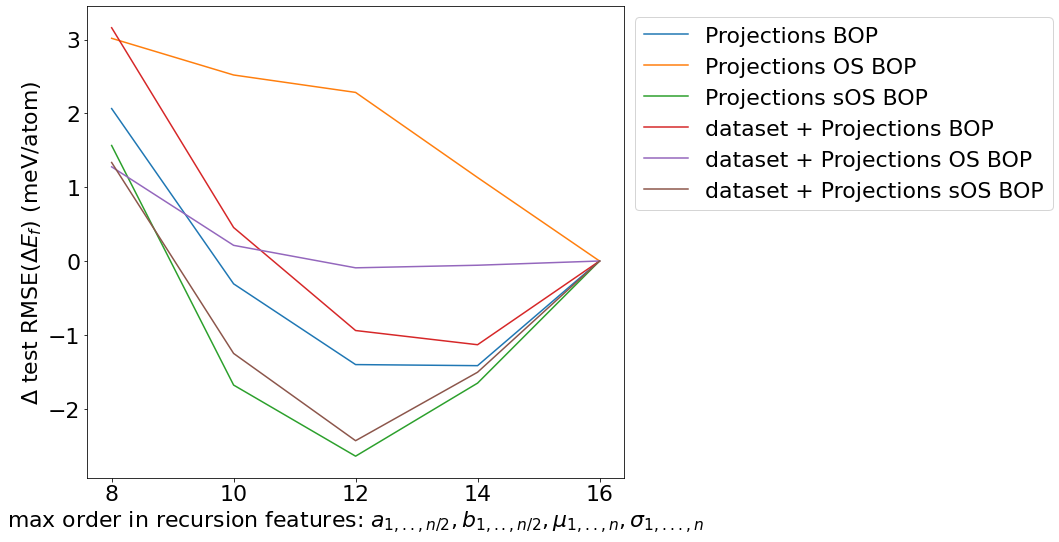

In [64]:
fig, ax = plt.subplots(figsize=(15,8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values -test_scores_vs_max[combi].values[-1])*1000 #- full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index,drmse , label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1,1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity.eps'))

# Feature Importances 

In [65]:
from sklearn.inspection import permutation_importance

In [66]:
def get_importances(estimator, features, target):
    allimportances = permutation_importance(estimator,features, target, scoring = 'neg_root_mean_squared_error', )
    importances = pd.DataFrame(data = allimportances['importances_mean'],columns=['importances_mean'], index = features.columns) #, 'importances_std']]
    importances.sort_values(by='importances_mean', inplace=True)
    return importances

In [67]:
importances = {}
for (modelname, name), estimator in FittedModels.items():
    print(name)
    allimportances = get_importances(estimator.best_estimator_ , DS.Features[name], DS.target)
    importances[(modelname, name)] =allimportances[allimportances['importances_mean']>=allimportances['importances_mean']['random']]

atomic
dataset
Pyscal
Canonical BOP
Projections BOP
Projections OS BOP
Projections sOS BOP
dataset + Canonical BOP
dataset + Projections BOP
dataset + Projections OS BOP
dataset + Projections sOS BOP


In [68]:
for (modelname, name),timportances in importances.items():
    timportances.sort_values(by='importances_mean', inplace=True, ascending=False)

/tmp/ipykernel_18094/281972631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timportances.sort_values(by='importances_mean', inplace=True, ascending=False)


In [69]:
from importlib.machinery import SourceFileLoader

In [70]:
get_str_formatted = SourceFileLoader('get_str_formatted', 'Tools/DatasetTools/Tools.py').load_module().get_str_formatted

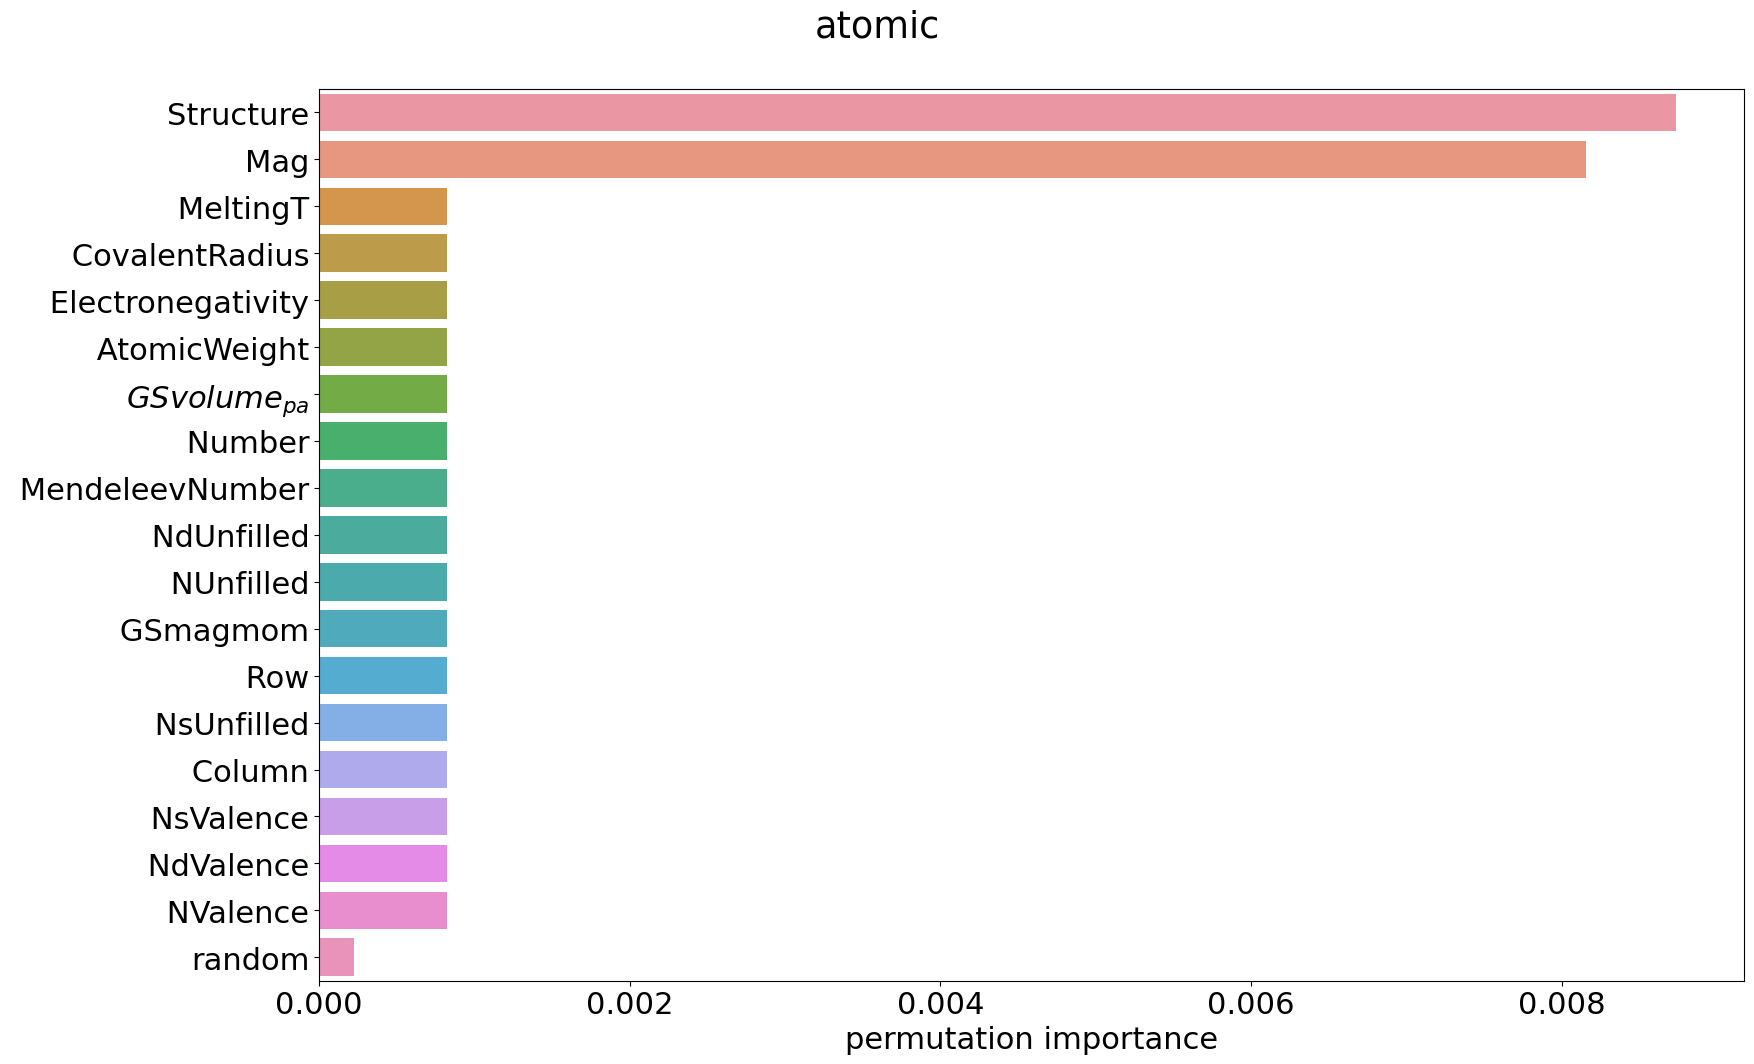

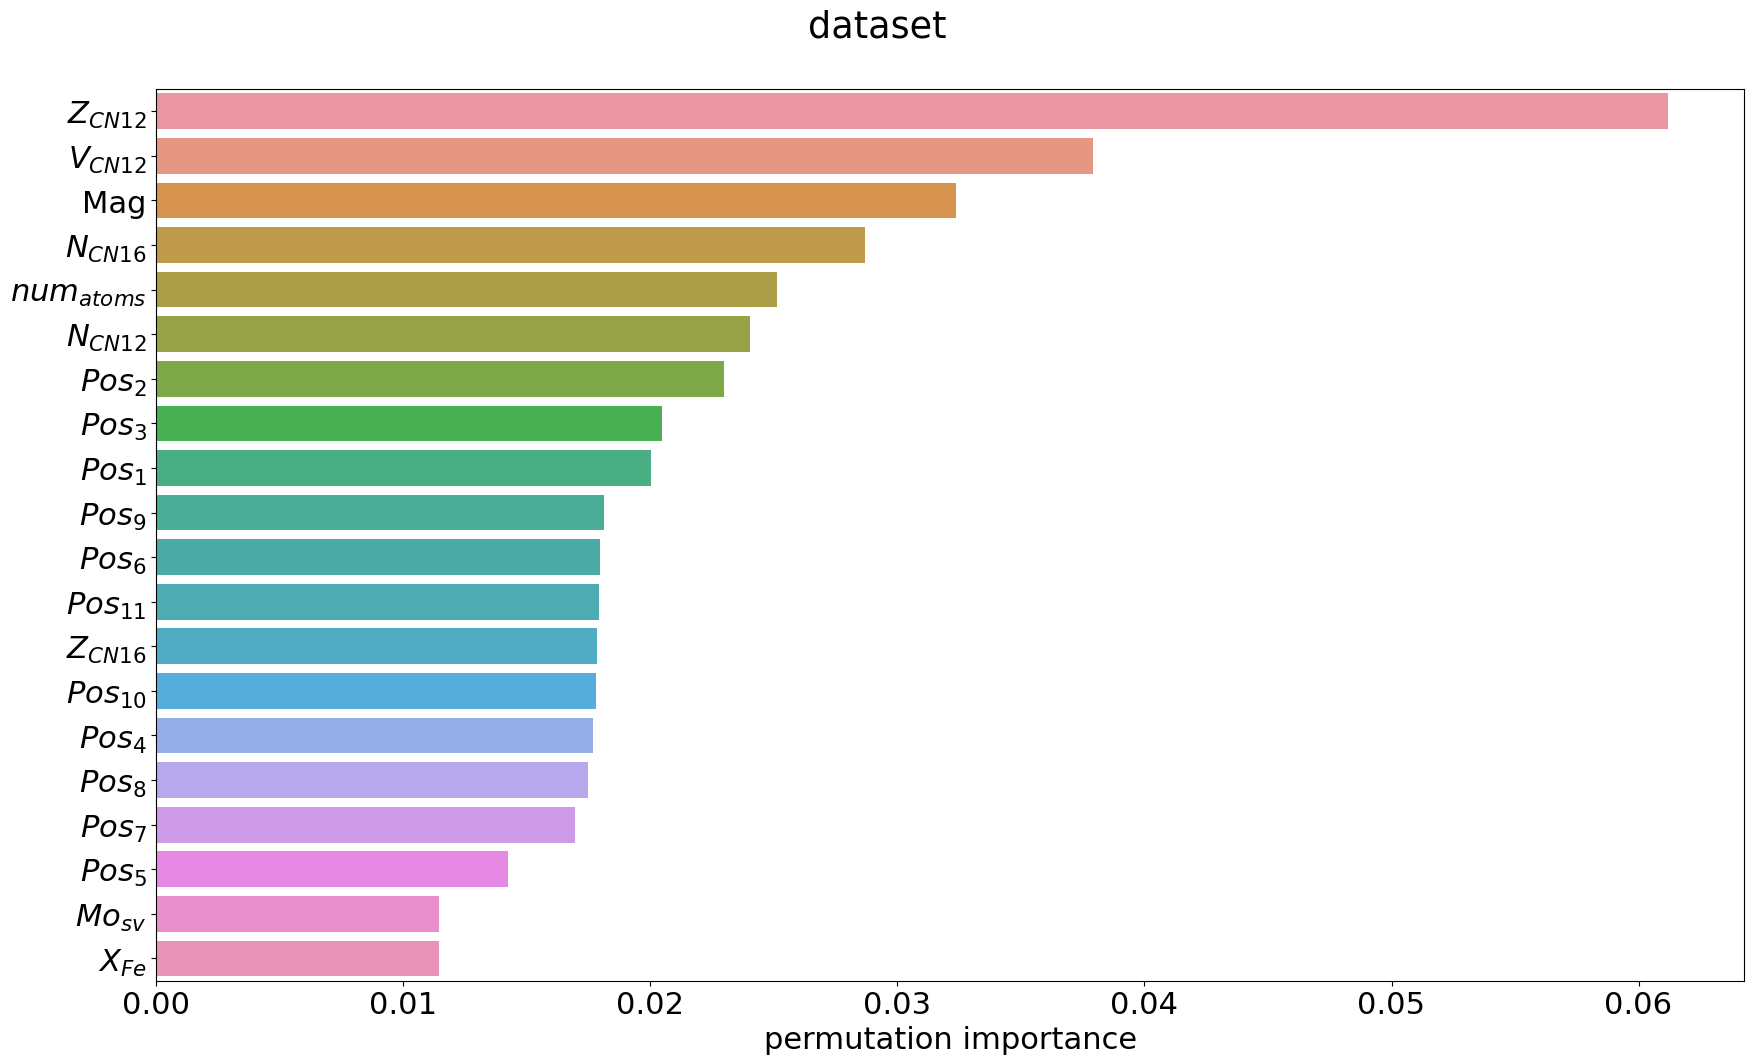

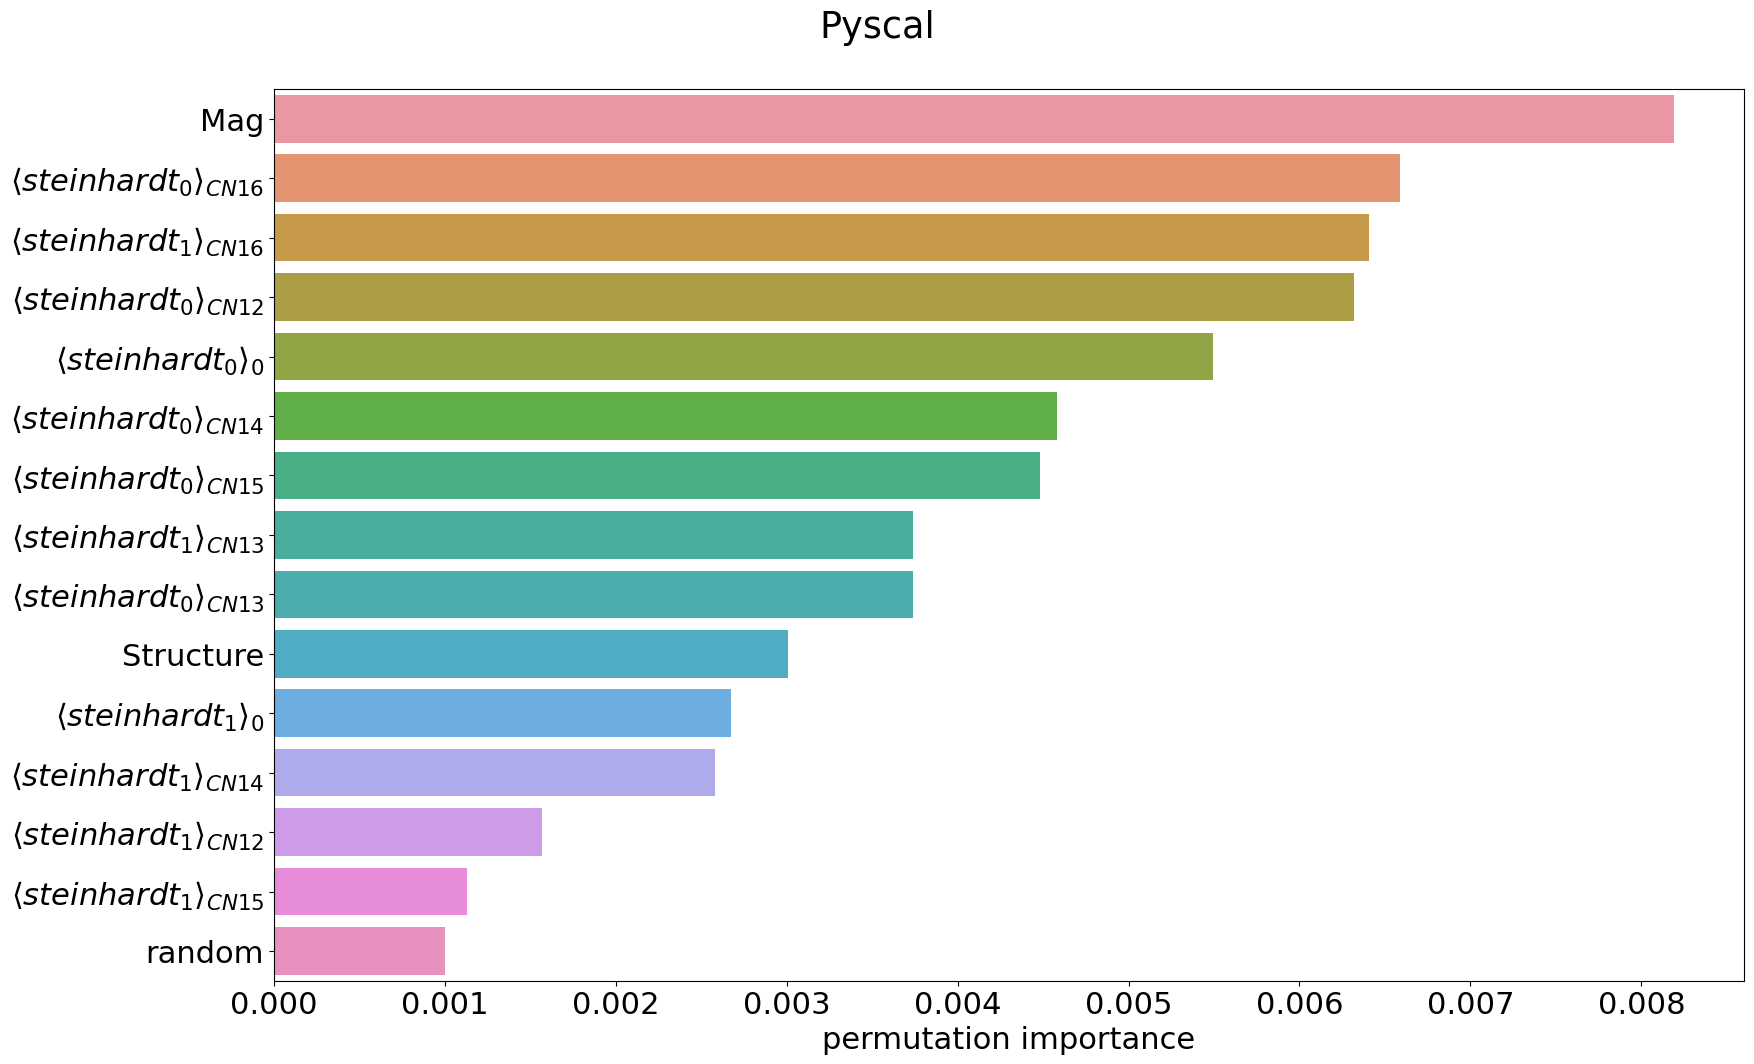

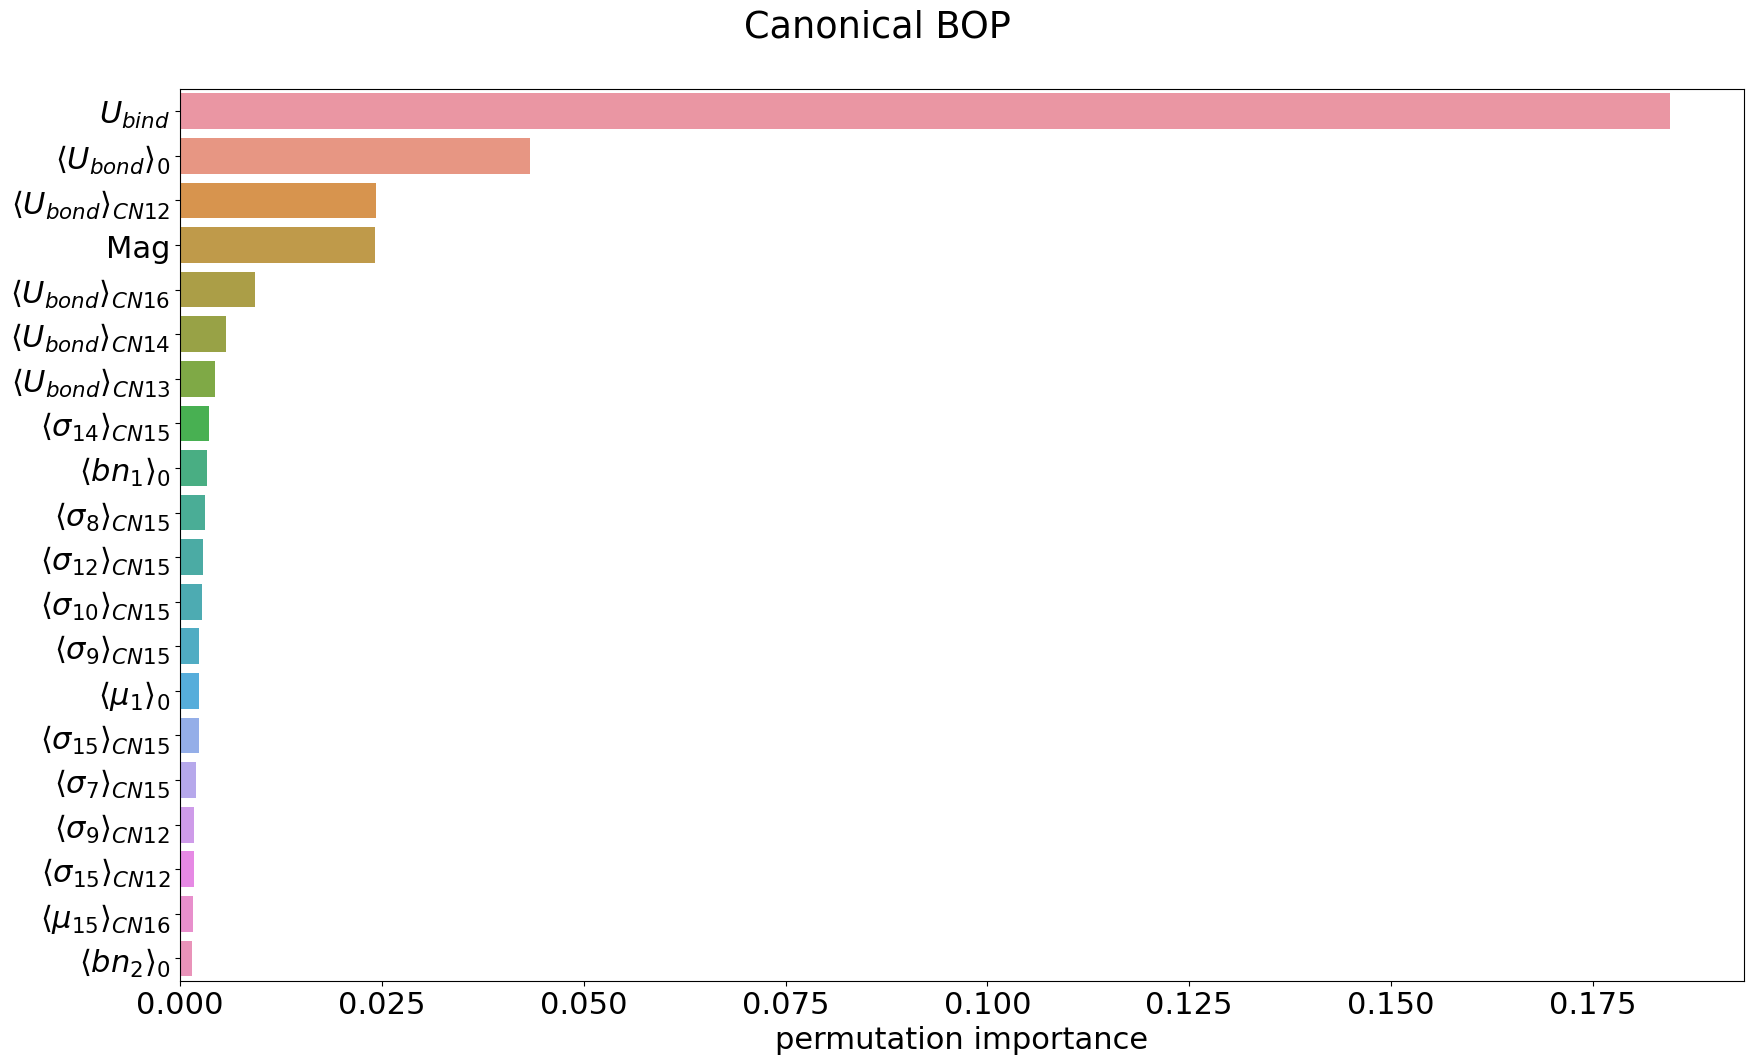

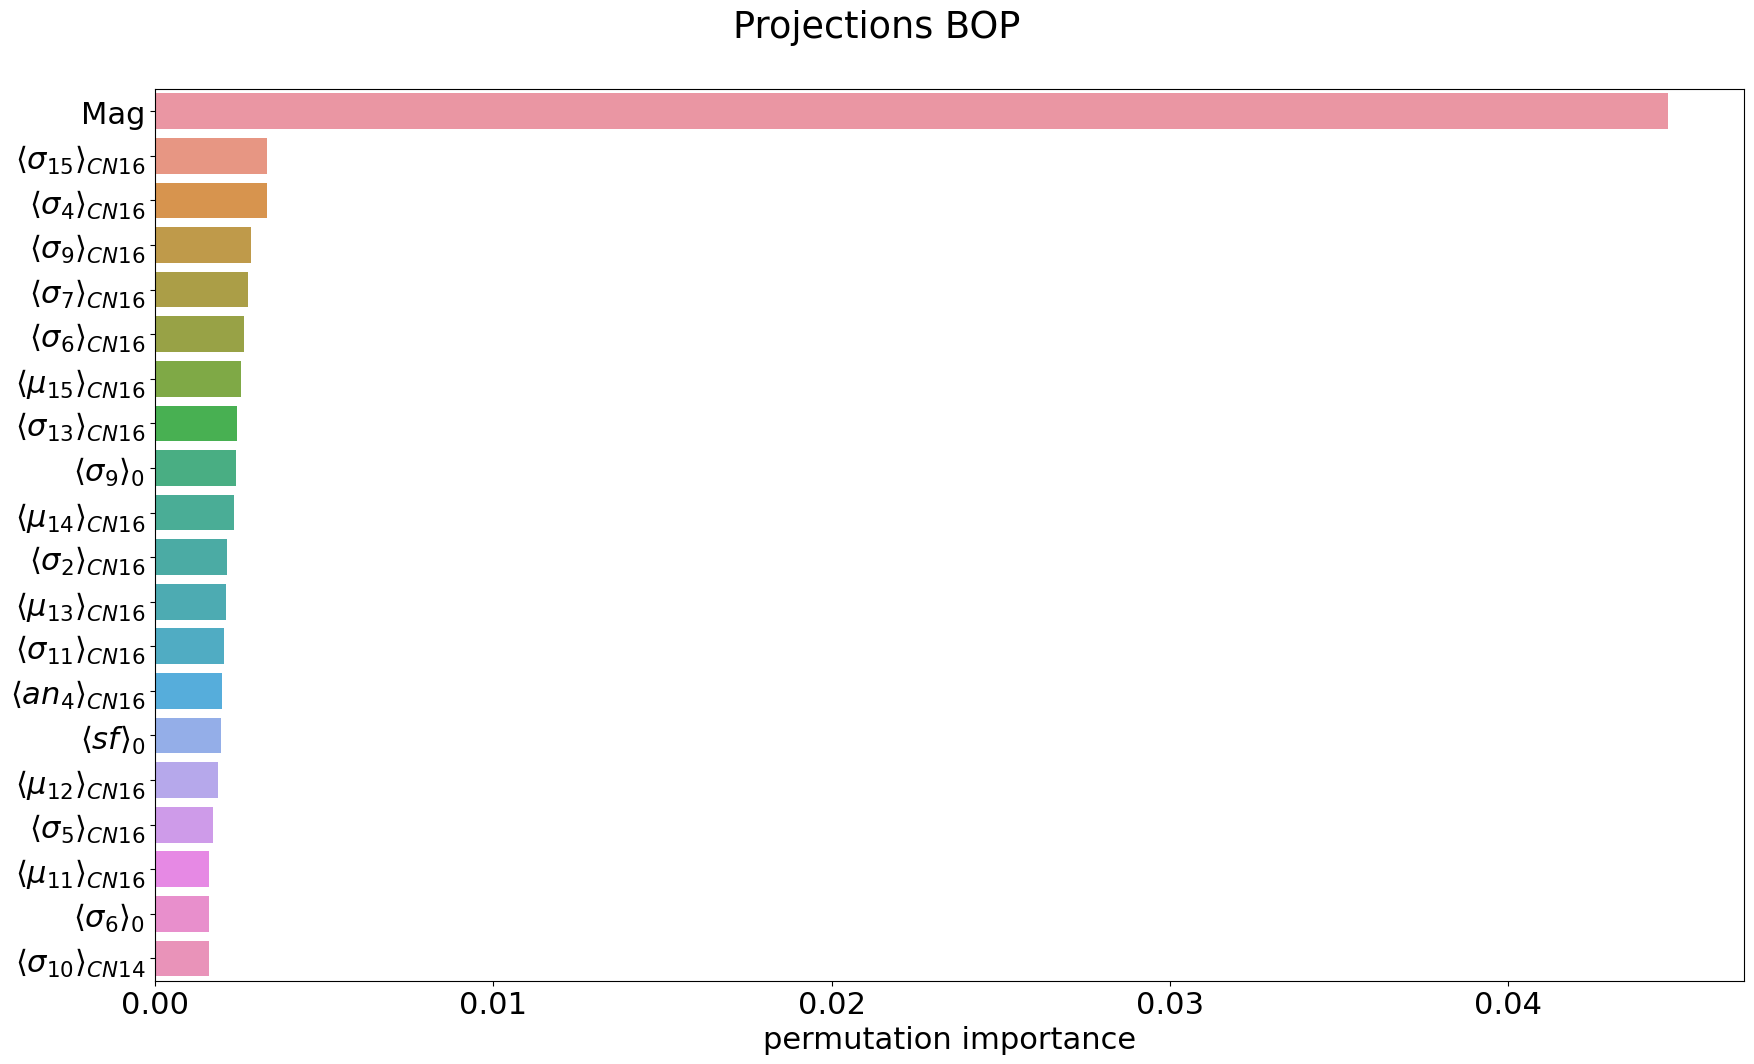

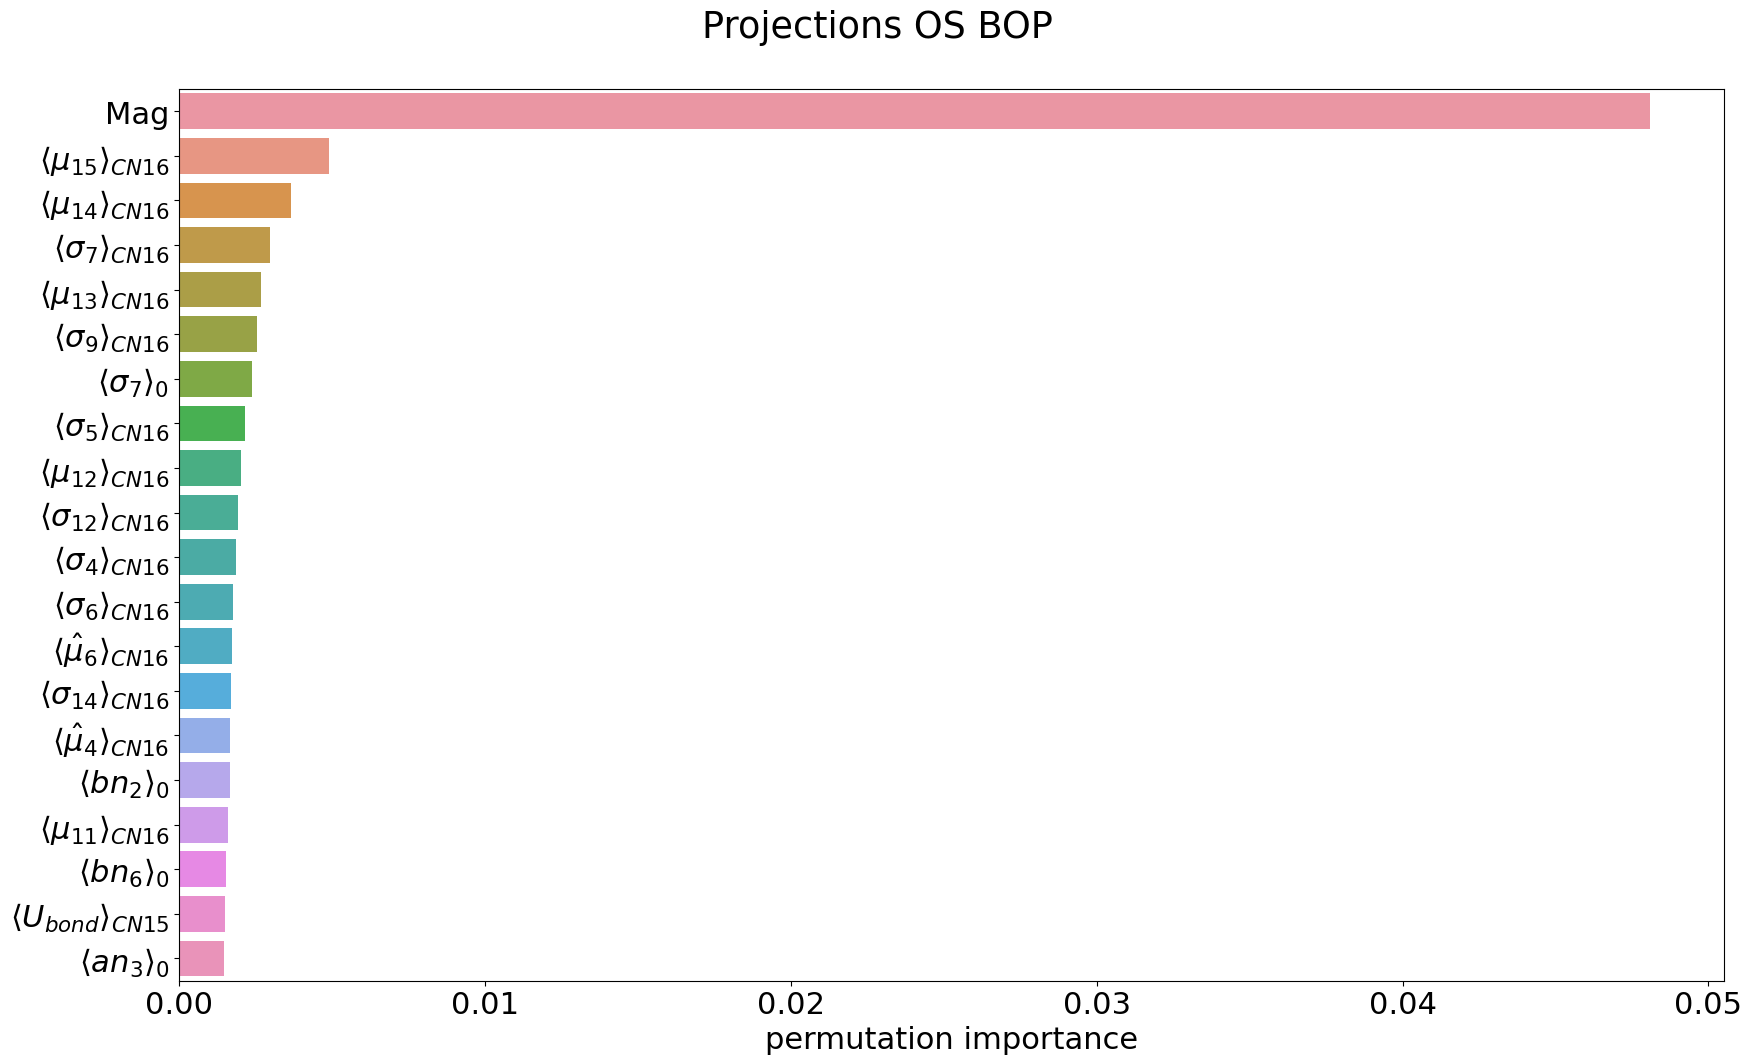

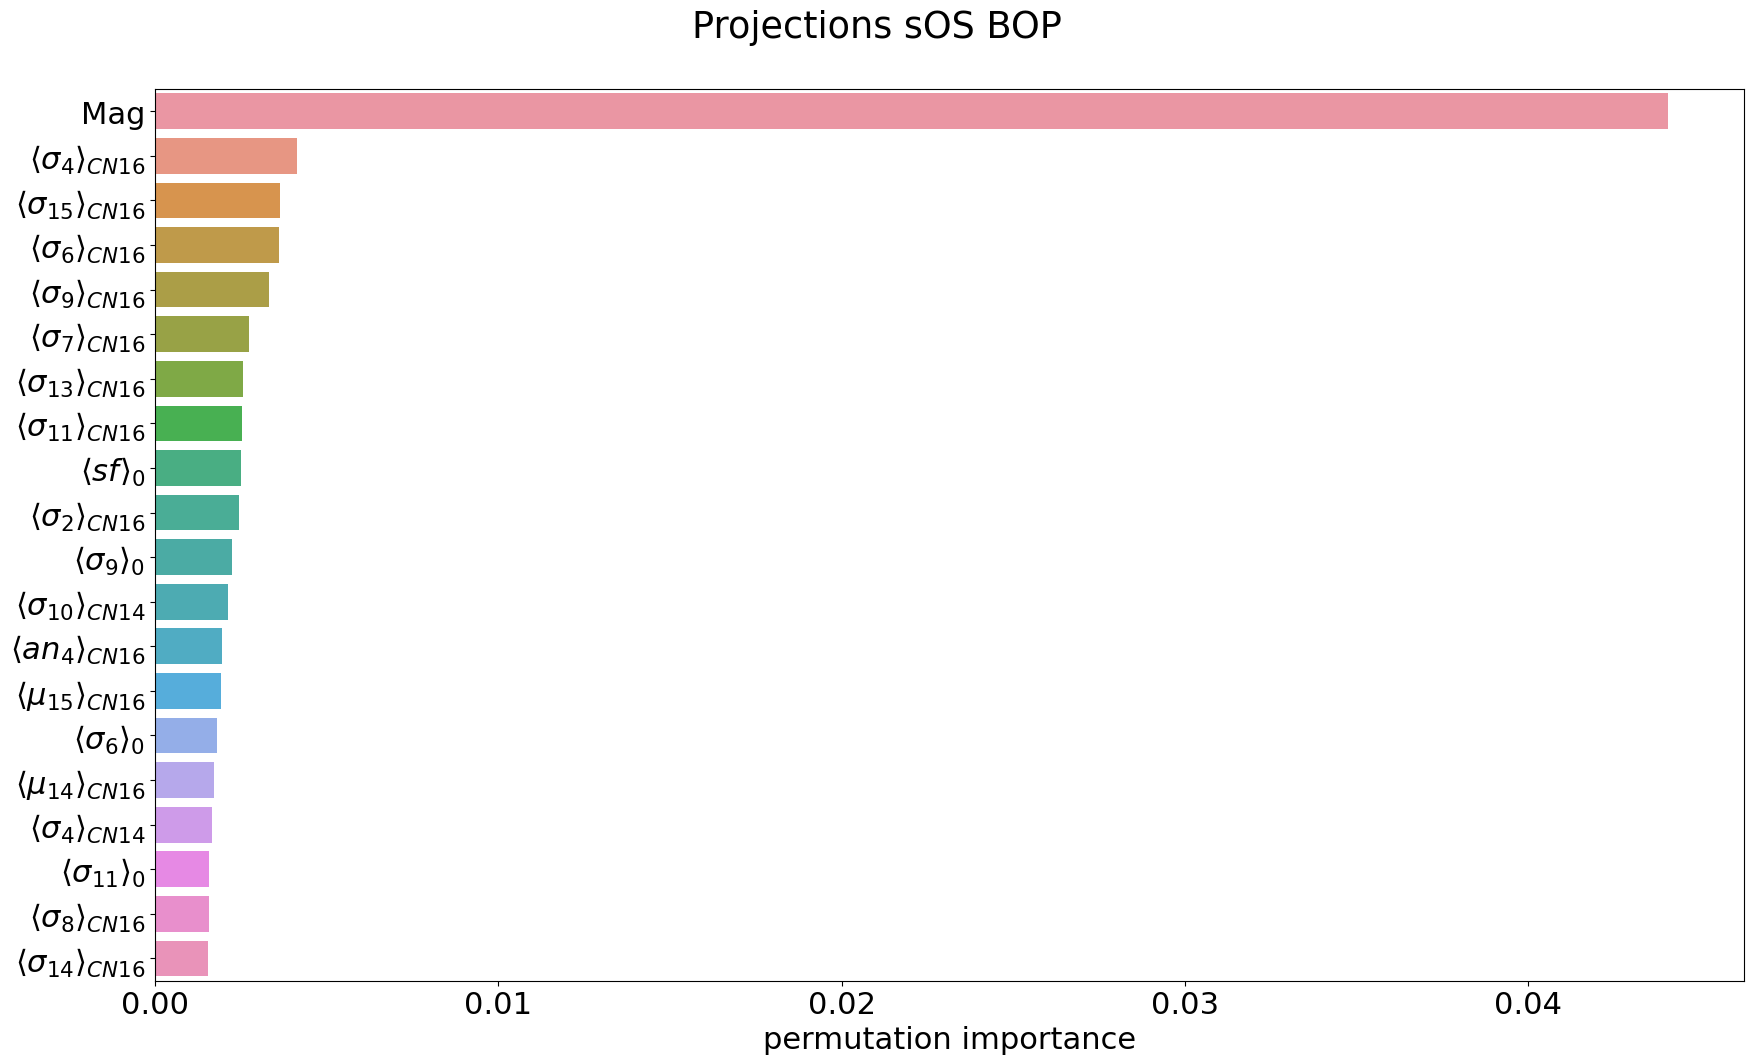

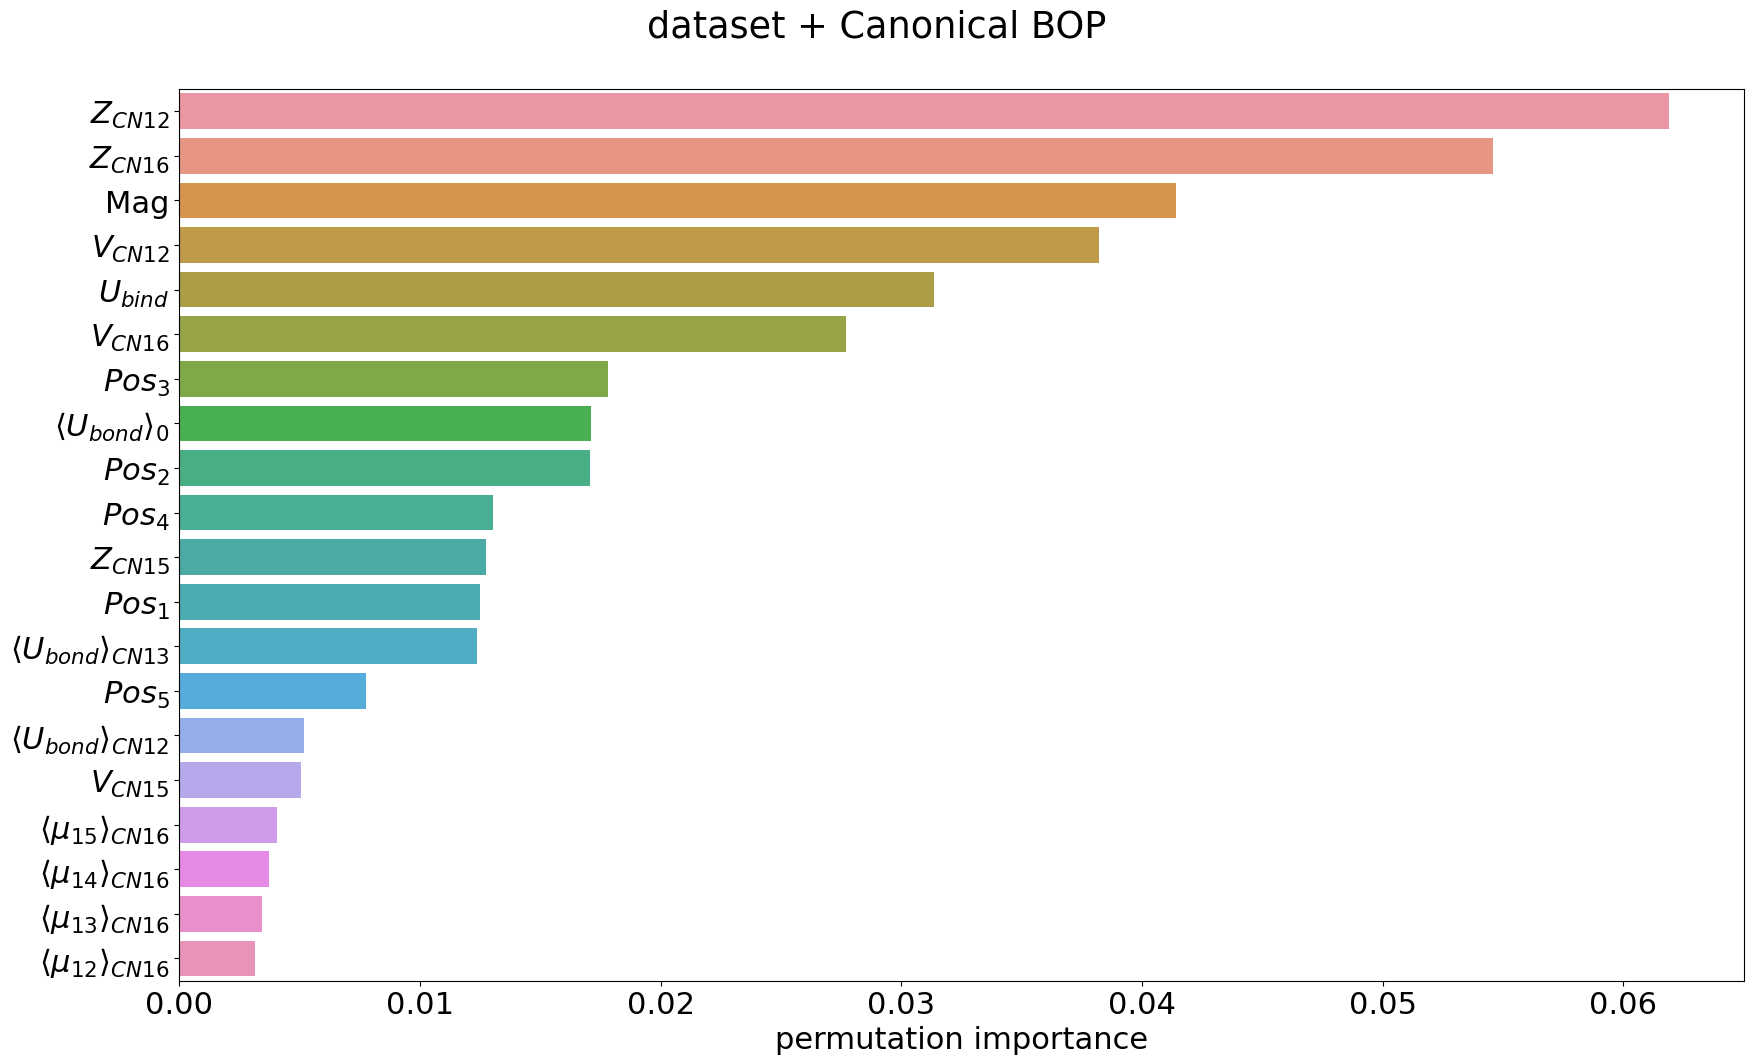

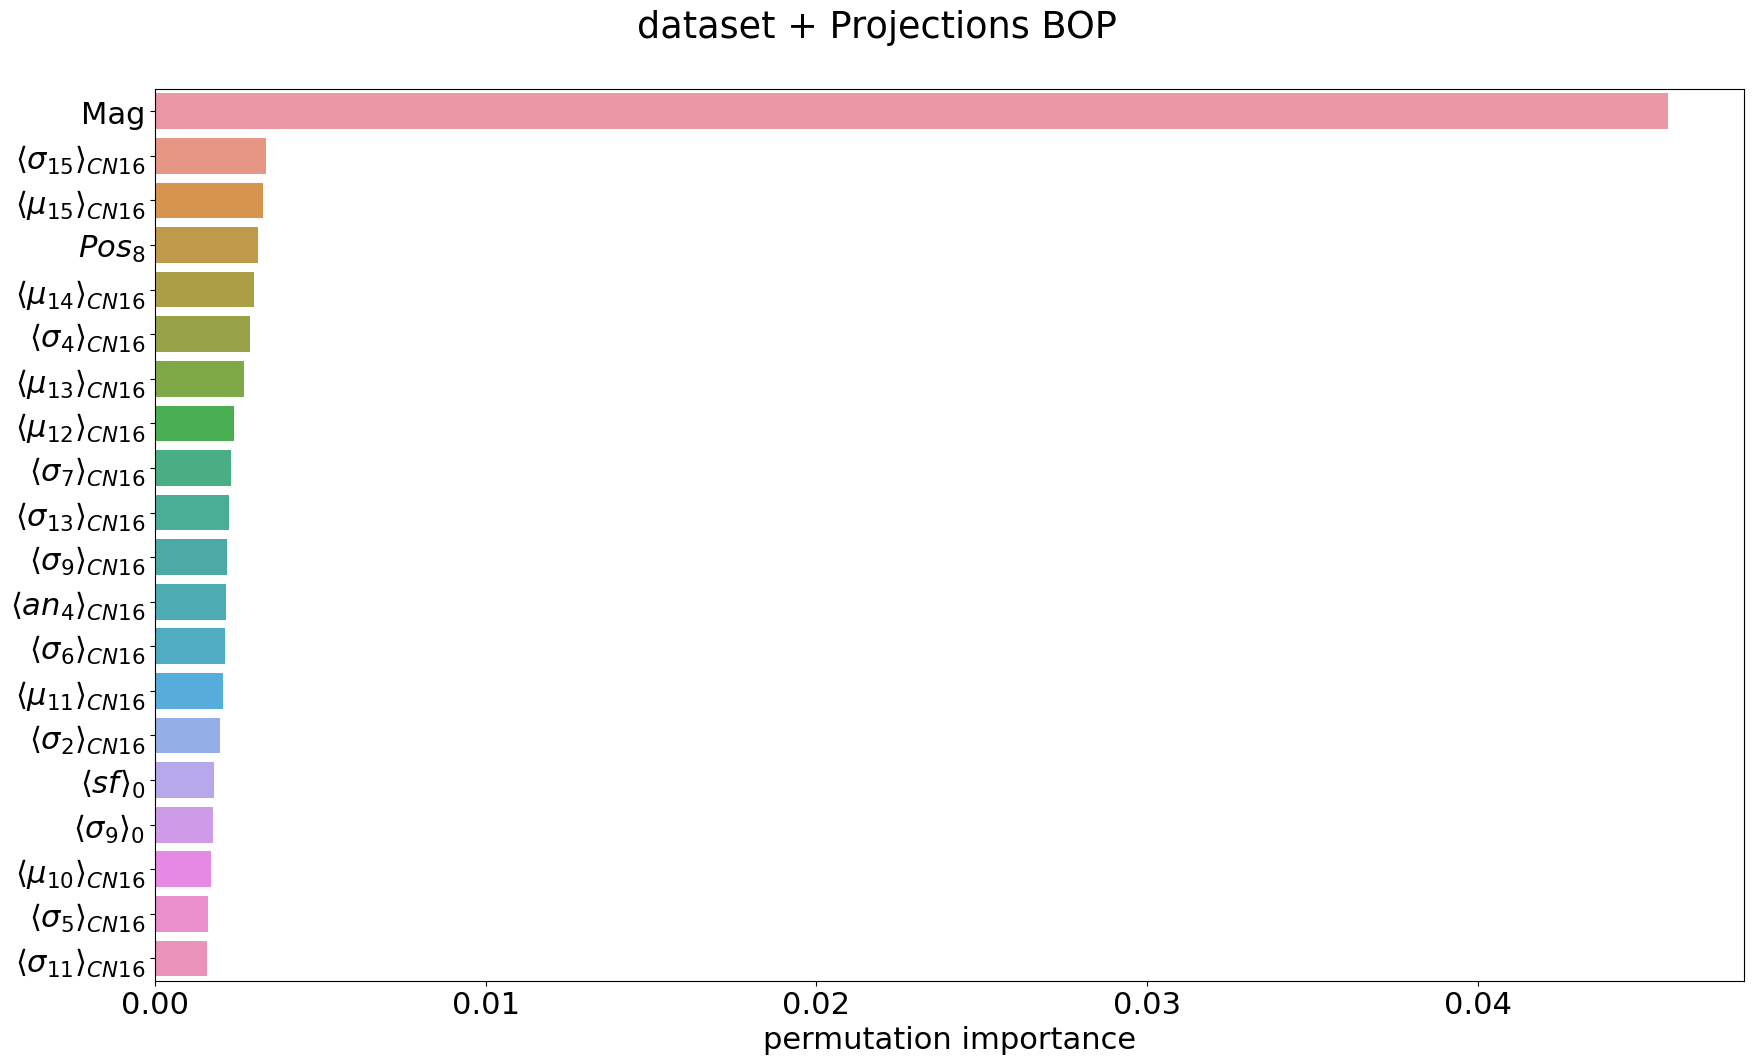

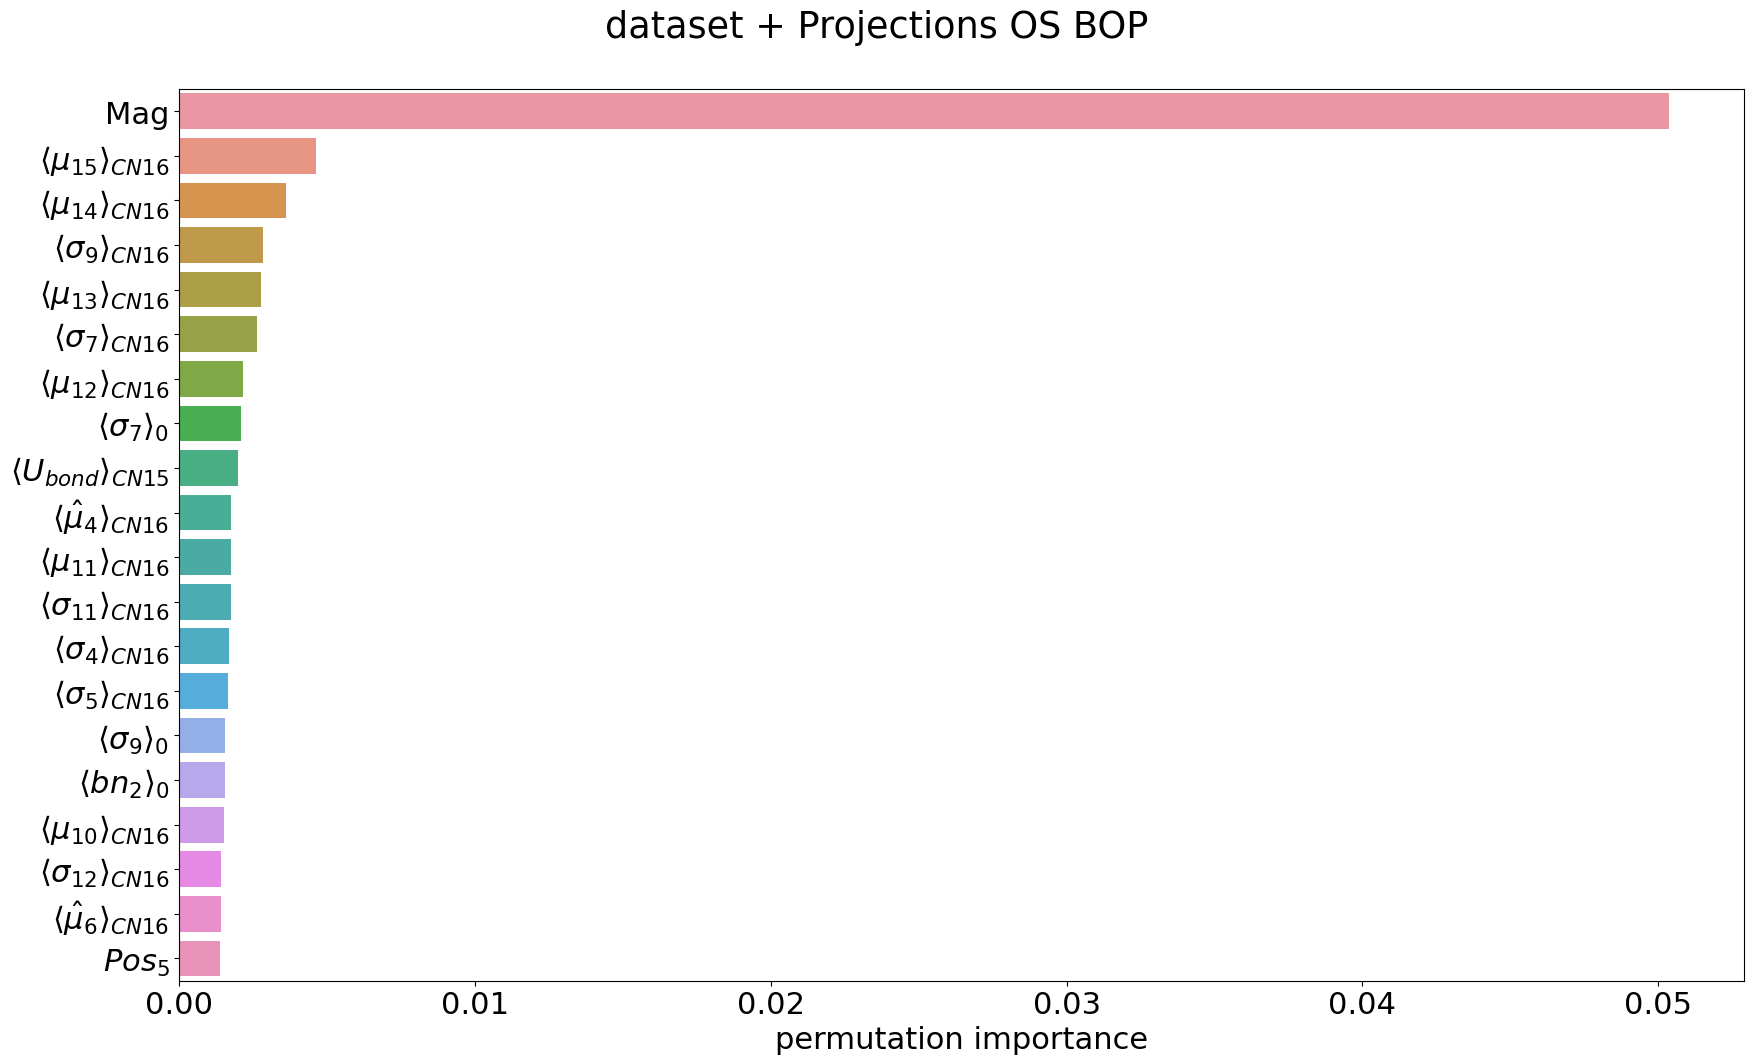

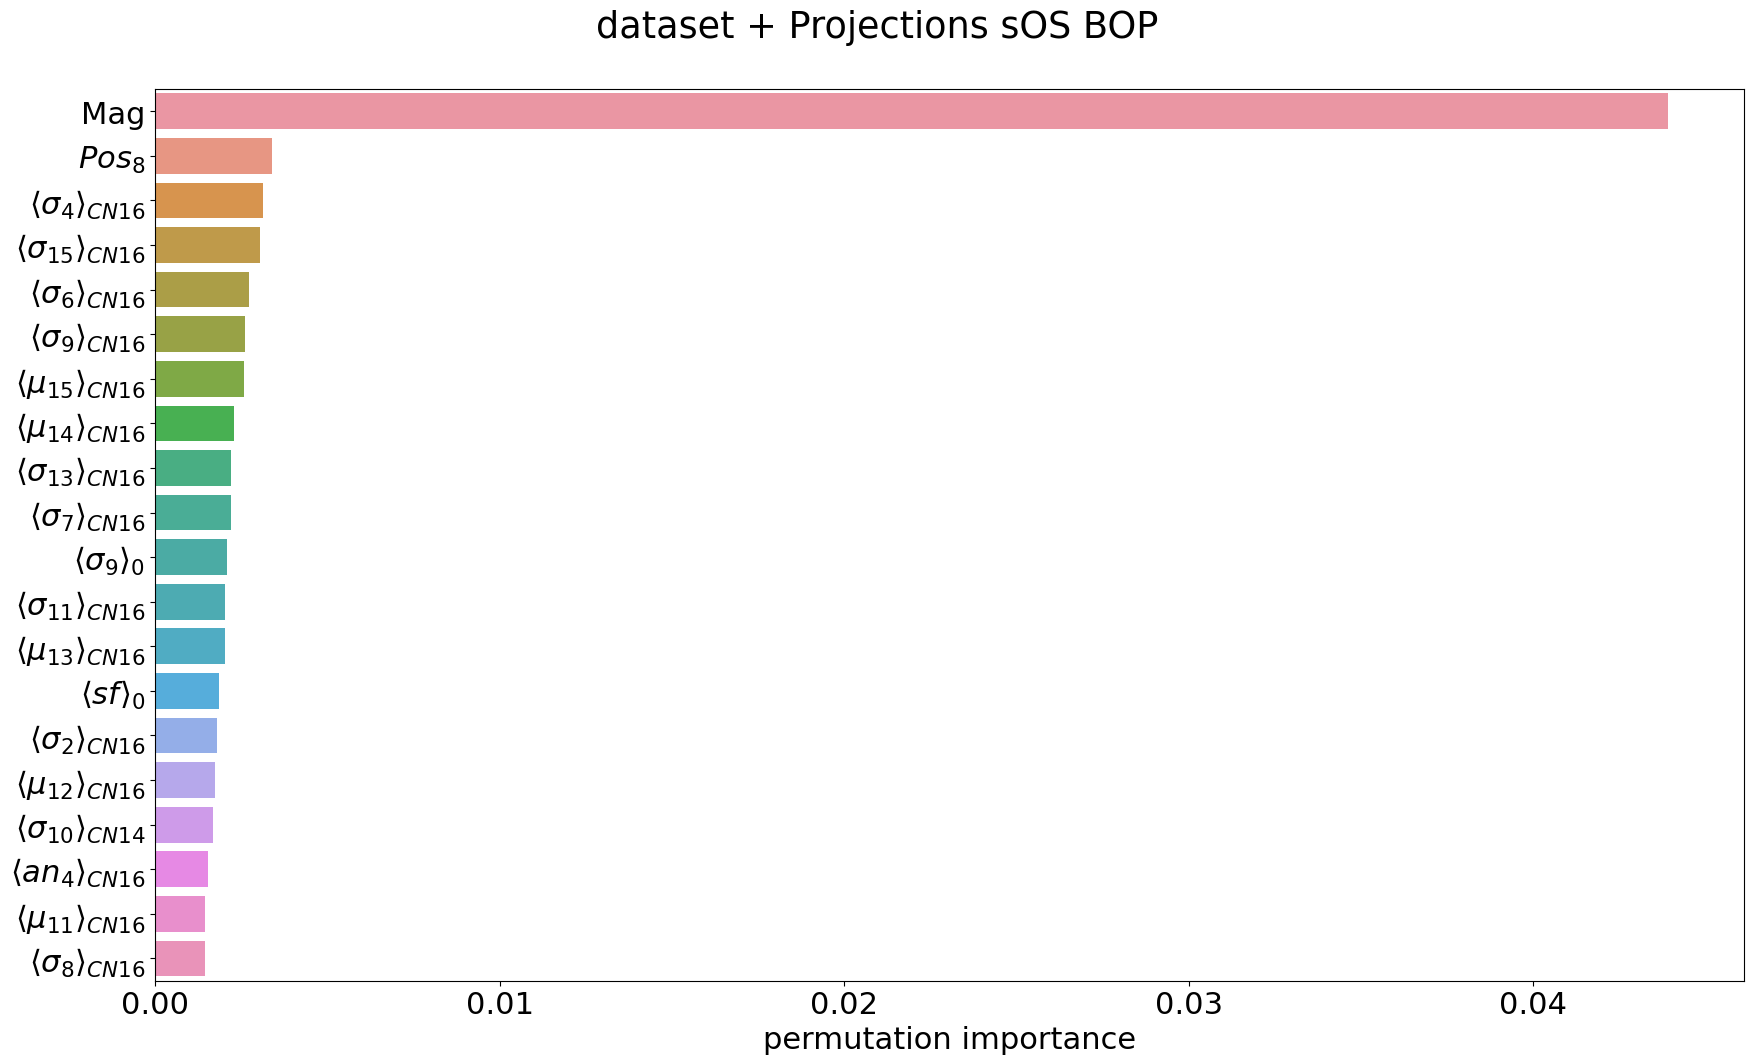

In [71]:
for (model, name), timp in importances.items():
    fig, ax = plt.subplots(figsize=(18, 11))
    x = timp['importances_mean'][:20]
    sns.barplot(y=timp.index[:20], x=x , ax=ax)
    ylabels = [get_str_formatted(fname) for fname in x.index]
    ax.set_xlabel('permutation importance')
    ax.set_yticklabels(ylabels)
    fig.suptitle(name)
    fig.tight_layout()
    nameforfile  = name.replace(' ','')
    fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_permutation_importance_{nameforfile}.eps')

In [72]:
FittedWithImportantFeatures = {
    ('Kernel Ridge', 'dataset'): GridSearchCV(Models['Kernel Ridge'], MO.modeloptions['Kernel Ridge'], scoring='neg_root_mean_squared_error', cv=samplefolds).fit(DS.Features['dataset'][important_features.drop('random')], DS.target)
}

NameError: name 'important_features' is not defined

In [ ]:
FittedWithImportantFeatures[('Kernel Ridge', 'dataset')].cv_results_['mean_test_score'].max()

In [ ]:
FittedModels[('Kernel Ridge', 'dataset')].cv_results_['mean_test_score'].max()

In [ ]:
FittedWithImportantFeatures[('Kernel Ridge', 'dataset')].best_params_

In [ ]:
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

# Feature Concatenation 

In [ ]:
FeatureConcatenate = SourceFileLoader('FeatureConcatenate', 'Tools/DatasetTools/FeatureConcatenate.py').load_module().FeatureConcatenate
#from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
import warnings
warnings.filterwarnings('ignore')

In [82]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', 'concatenation_results.pkl')
if os.path.exists(feature_concat_resul_loc):
    with open (feature_concat_resul_loc, 'rb') as pkl:
        FCresults = pickle.load(pkl)

In [83]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'Projections OS BOP')])

In [95]:
FCresults = {}

In [ ]:

#for featurename, feature in Features.items():
for featurename in ['Projections OS BOP']:
    model = copy.deepcopy(Models['Kernel Ridge'])
    feature = DS.Features[featurename]
    combi = ('Kernel Ridge', featurename )
    if combi in FCresults.keys():
        continue
    param_grid = {param: [value] for param, value in FittedModels[combi].best_params_.items()}
    data = pd.concat([feature, DS.target], axis = 1)
    feature_list = feature.columns
    FC = FeatureConcatenate(data, model, param_grid,sample_weights = DS.BS['Phase'][DS.target.index], feature_list=feature_list, data_target='EF', report_path=DS.dataset+'/reports/')

    FCresults[combi] = FC.build_features_list(maxnumfeatures=30, best_feature_proposal=['Mag', 'Structure'], pass_force_refit=True)

    with open (feature_concat_resul_loc,'wb') as pkl:
        pickle.dump(FCresults , pkl)

procesing '['Mag']' with 'Structure' ... :: 100%|#########################################| 1/1 [00:00<00:00, 18.88it/s]


Refitting if necesary..
fitting has finished,  test_score  =  0.16308697114121737


procesing '['Mag', 'Structure']' with 'moments_2_CN13' ... ::   1%|2                    | 4/392 [00:00<00:40,  9.47it/s]

Refitting if necesary..


procesing '['Mag', 'Structure']' with 'bn_3_CN14' ... ::  41%|#########7              | 160/392 [00:07<00:10, 22.95it/s]

In [93]:
FCresults[combi][1][0]

Structure    0.163087
Structure    0.166701
Structure    0.166701
Structure    0.166701
Structure    0.166701
Structure    0.170109
Structure    0.170109
Structure    0.170109
Structure    0.170109
Structure    0.170109
Name: test_score, dtype: float64

ValueError: setting an array element with a sequence.

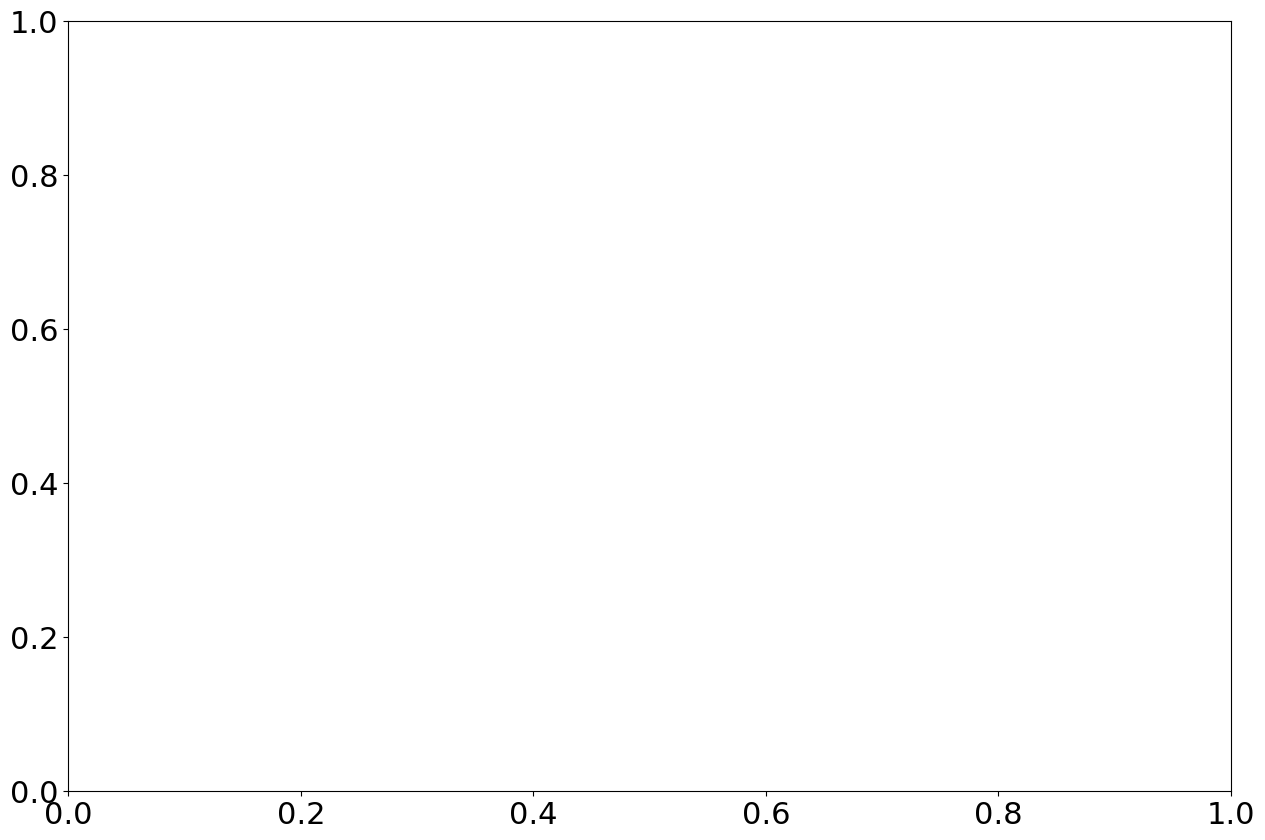

In [86]:
for combi, result in FCresults.items():
    x = np.linspace(1,len(result[0])-1, len(result[0])-1)
    plt.plot(x, result[1],'o', label=combi[1])
plt.legend()
plt.yscale('log')

In [230]:
pd.DataFrame.from_dict(FCresults, orient='index')[0][[('Kernel Ridge', 'Projections BOP'), ('Kernel Ridge', 'Projections OS BOP')]]

(Kernel Ridge, Projections BOP)       [Mag, Structure, sigma_7_CN16, moments_1_CN12,...
(Kernel Ridge, Projections OS BOP)    [Mag, Structure, sigma_10_CN16, sigma_1_CN16, ...
Name: 0, dtype: object

# only the first orders 

In [210]:
Reduced_5 = Features['Canonical BOP'].filter(regex='Structure|Mag|.*_[1-5]_.*')

In [211]:
Reduced_5.columns

Index(['Structure', 'Mag', 'U_bond_atom_list_1_0', 'U_bond_atom_list_1_CN12',
       'U_bond_atom_list_1_CN13', 'U_bond_atom_list_1_CN14',
       'U_bond_atom_list_1_CN15', 'U_bond_atom_list_1_CN16', 'moments_1_0',
       'moments_1_CN12',
       ...
       'Ainf_1_CN13', 'Ainf_1_CN14', 'Ainf_1_CN15', 'Ainf_1_CN16', 'Binf_1_0',
       'Binf_1_CN12', 'Binf_1_CN13', 'Binf_1_CN14', 'Binf_1_CN15',
       'Binf_1_CN16'],
      dtype='object', length=170)

In [ ]:
model = GridSearchCV(Models)

In [ ]:
FittedModelsReduced5 = 

# select K Best 

In [174]:
from sklearn.feature_selection import SelectKBest

In [198]:
selector = SelectKBest(k=10)

In [199]:
selector.fit(DS.Features['Projections BOP'], DS.target)

SelectKBest()

In [200]:
selector.get_feature_names_out()

array(['Binf_1_CN13', 'Binf_1_CN14', 'Binf_1_CN15', 'Binf_1_CN16', 'sf_0',
       'sf_CN12', 'sf_CN13', 'sf_CN14', 'sf_CN15', 'sf_CN16'],
      dtype=object)

In [ ]:
newmodel = Pipeline([('selector', SelectKBest(20)), ('scaler', StandardScaler())])

In [203]:
thismodel = Models['Kernel Ridge'].named_steps

In [204]:
thismodel

{'scaler': StandardScaler(),
 'regressor': KernelRidge(alpha=0.1, degree=5, kernel='polynomial')}